In [159]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


In [160]:
df = pd.read_csv('wine.csv')
df.sample(5)

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
9,1,13.86,1.35,2.27,16.0,98,2.98,3.15,0.22,1.85,7.22,1.01,3.55,1045
133,3,12.70,3.55,2.36,21.5,106,1.70,1.20,0.17,0.84,5.00,0.78,1.29,600
154,3,12.58,1.29,2.10,20.0,103,1.48,0.58,0.53,1.40,7.60,0.58,1.55,640
124,2,11.87,4.31,2.39,21.0,82,2.86,3.03,0.21,2.91,2.80,0.75,3.64,380
115,2,11.03,1.51,2.20,21.5,85,2.46,2.17,0.52,2.01,1.90,1.71,2.87,407


In [161]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Wine                  178 non-null    int64  
 1   Alcohol               178 non-null    float64
 2   Malic.acid            178 non-null    float64
 3   Ash                   178 non-null    float64
 4   Acl                   178 non-null    float64
 5   Mg                    178 non-null    int64  
 6   Phenols               178 non-null    float64
 7   Flavanoids            178 non-null    float64
 8   Nonflavanoid.phenols  178 non-null    float64
 9   Proanth               178 non-null    float64
 10  Color.int             178 non-null    float64
 11  Hue                   178 non-null    float64
 12  OD                    178 non-null    float64
 13  Proline               178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [162]:
df.Wine.unique()

array([1, 2, 3])

In [163]:
y = df.Wine
y.head()

0    1
1    1
2    1
3    1
4    1
Name: Wine, dtype: int64

In [164]:
x = df.drop('Wine', axis=1)
x.head()

,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [165]:
x_train,x_test,y_train,y_test =  train_test_split(x,y,test_size=0.2,random_state=42)


In [166]:
# Before scaling as KNN is prone to different value ranges 

k_values = range(1,13)
cv_scores = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    score = cross_val_score(knn,x_train,y_train,cv=5,scoring='accuracy')
    cv_scores.append(score.mean())
   
   
optimal_k = k_values[np.argmax(cv_scores)]   
print(optimal_k)
# print(cv_scores)
print(max(cv_scores))



1
0.7248768472906404


In [167]:

knn = KNeighborsClassifier(n_neighbors=optimal_k)
knn.fit(x_train,y_train)
y_pred = knn.predict(x_test)
print(accuracy_score(y_pred,y_test))

0.7777777777777778


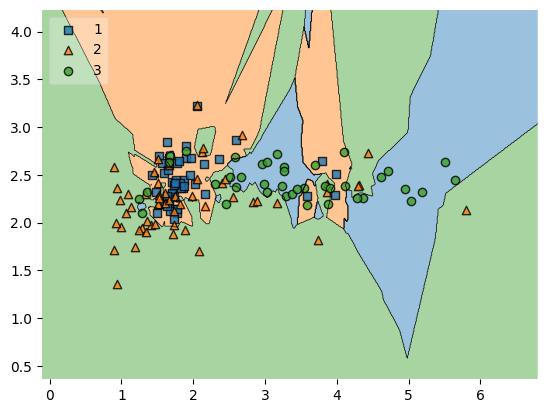

In [168]:
from mlxtend.plotting import plot_decision_regions
import matplotlib.pyplot as plt

x_train_plot = x_train.to_numpy()[:,[1,2]]
# .to_numpy()[:,[1,2]]
knn_plot = KNeighborsClassifier(n_neighbors=2)
knn_plot.fit(x_train_plot,y_train)

plot_decision_regions(x_train_plot,y_train.to_numpy(),clf = knn_plot, legend = 2)
plt.show()


In [169]:
# after standard scaling

sc = StandardScaler()

x_train_scaled = sc.fit_transform(x_train)
x_test_scaled = sc.transform(x_test)

In [174]:
k_values = range(1,13)
cv_scores = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    score = cross_val_score(knn,x_train_scaled,y_train,cv=5,scoring='accuracy')
    cv_scores.append(score.mean())
    
    
    
optimal_k = k_values[np.argmax(cv_scores)]   
print(optimal_k)
# print(cv_scores)
print(max(cv_scores))


12
0.9578817733990148


In [ ]:
knn = KNeighborsClassifier(n_neighbors=optimal_k)
knn.fit(x_train_scaled,y_train)
y_pred = knn.predict(x_test_scaled)
print(accuracy_score(y_pred,y_test))

0.9722222222222222


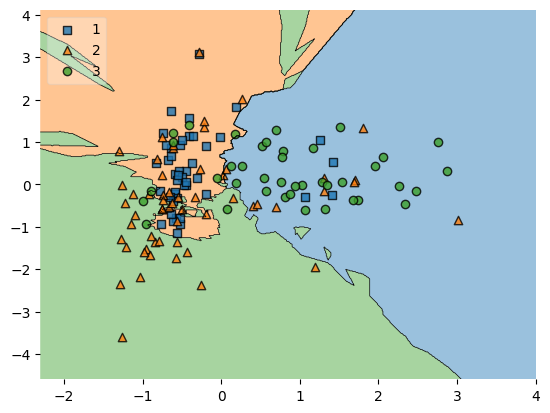

In [177]:
from mlxtend.plotting import plot_decision_regions
import matplotlib.pyplot as plt

x_train_plot = x_train_scaled[:, [1,2]]
y = y_train.to_numpy()

knn_plot = KNeighborsClassifier(n_neighbors=optimal_k)
knn_plot.fit(x_train_plot, y)

plot_decision_regions(x_train_plot, y, clf=knn_plot, legend=2)
plt.show()


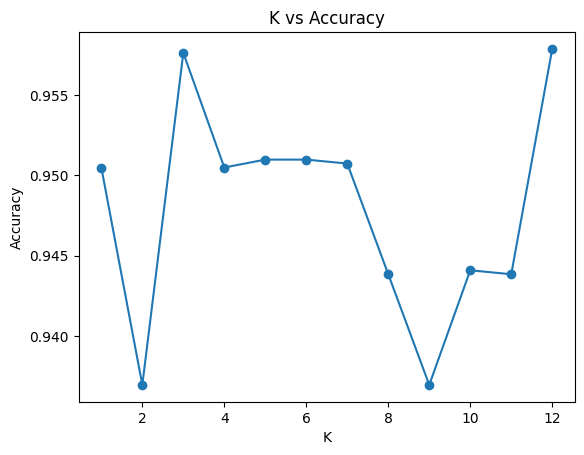

In [178]:
import matplotlib.pyplot as plt

plt.plot(k_values, cv_scores, marker='o')
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.title("K vs Accuracy")
plt.show()